# Control systems development

In [980]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct


np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

T = 0.0533333

servo_delay = ct.StateSpace(-10, 10, 1, 0)

## Longitudinal system

In [981]:
longitudinal_linear_matrices = np.load("longitudinal_linear.npz")
A = longitudinal_linear_matrices["A"]
B = longitudinal_linear_matrices["B"]
C = longitudinal_linear_matrices["C"]
D = longitudinal_linear_matrices["D"]

longitudinal_linear = ct.StateSpace(A, B, C, D)

### PID controller

In [982]:
P_gain = 0.6
I_gain = 1
D_gain = 0.12

longitudinal_controller = ct.StateSpace(np.zeros((1,1)), np.array([0, 0, 1]), np.array([[-I_gain]]), np.array([[0, -D_gain, -P_gain]]))

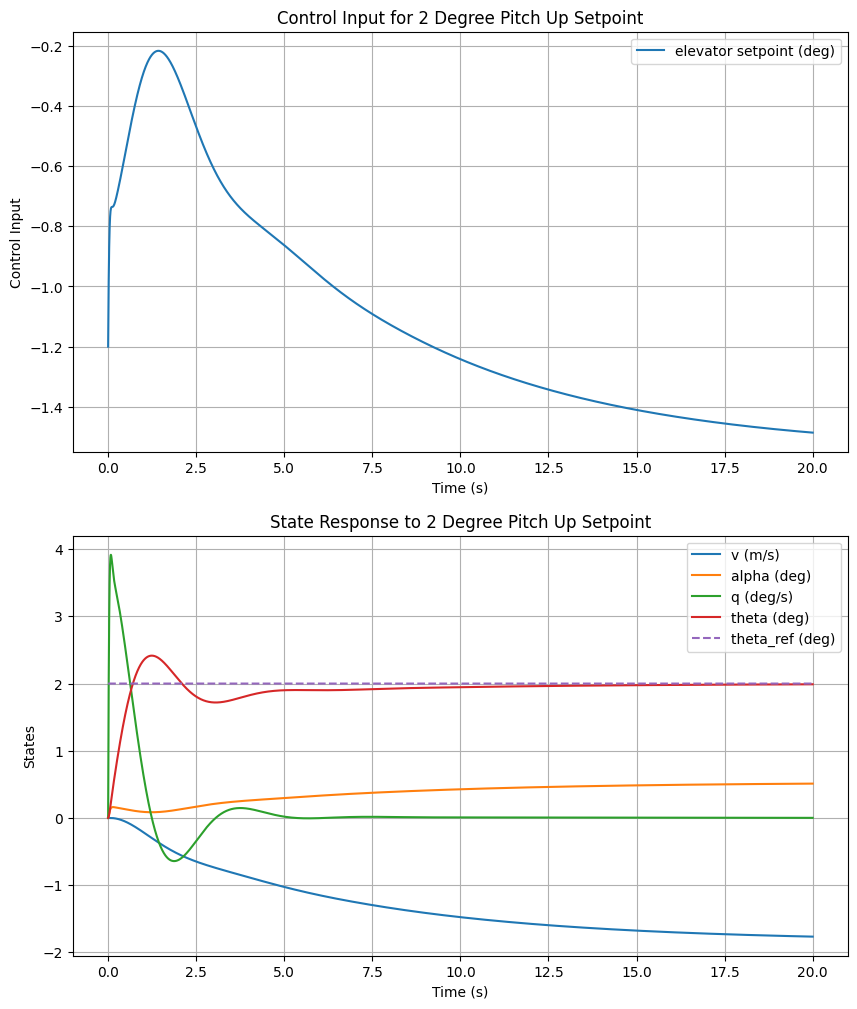

In [983]:
longitudinal_feedback = ct.feedback(longitudinal_controller, longitudinal_linear, sign=-1)

t = np.linspace(0, 20, 10000)
u = np.zeros((3, len(t)))
u[2,:] = 2 * np.pi / 180

# run longitudinal feedback with setpoint tracking
t, y, x = ct.forced_response(longitudinal_feedback, T=t, U=u, return_states = True)

# plot output
plt.figure(figsize=(10, 12))
plt.subplot(2, 1, 1)
plt.plot(t, y[0, :] * 180 / np.pi, label="elevator setpoint (deg)")
plt.xlabel("Time (s)")
plt.ylabel("Control Input")
plt.title("Control Input for 2 Degree Pitch Up Setpoint")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)

# plot states
plt.plot(t, x[1, :], label="v (m/s)")
plt.plot(t, x[2, :] * 180 / np.pi, label="alpha (deg)")
plt.plot(t, x[3, :] * 180 / np.pi, label="q (deg/s)")
plt.plot(t, x[4, :] * 180 / np.pi, label="theta (deg)")
# reference
plt.plot(t, u[2, :] * 180 / np.pi, label="theta_ref (deg)", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("States")
plt.title("State Response to 2 Degree Pitch Up Setpoint")
plt.legend()
plt.grid()
plt.show()

### Stability map

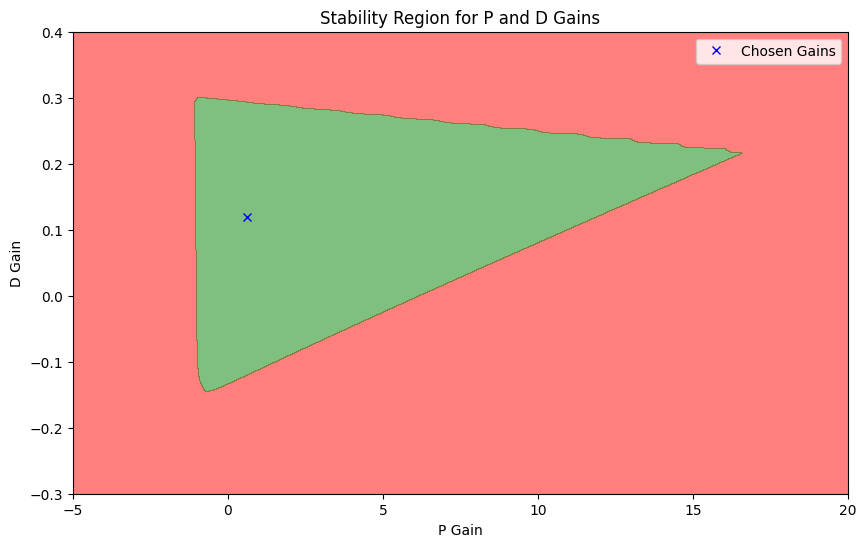

In [ ]:
# try all the different gains
kps, kds = np.meshgrid(np.linspace(-5, 20, 150), np.linspace(-0.3, 0.4, 150), indexing="ij")
longitudinal_discrete = ct.sample_system(longitudinal_linear, T)

stability_results = np.zeros(kps.shape)

for i, (kp, kd) in enumerate(zip(kps.flatten(), kds.flatten())):
    longitudinal_controller = ct.StateSpace(np.zeros((1,1)), np.array([0, 0, 1]), np.array([[-I_gain]]), np.array([[0, -kd, -kp]]), dt=T)
    longitudinal_feedback = ct.feedback(longitudinal_controller, longitudinal_discrete, sign=-1)

    # check stability
    A = longitudinal_feedback.A
    eigenvalues = np.linalg.eigvals(A)
    if np.max(np.abs(eigenvalues)) < 1:
        stability_results[i // kps.shape[1], i % kps.shape[1]] = 1
    else:
        stability_results[i // kps.shape[1], i % kps.shape[1]] = 0
    stability_results[i // kps.shape[1], i % kps.shape[1]] = 1 - np.max(np.abs(eigenvalues))

plt.figure(figsize=(10, 6))
plt.contourf(kps, kds, stability_results, levels=[-10, 0, 1], colors=["red", "green"], alpha=0.5)
# show the point we chose
plt.plot(P_gain, D_gain, "x", color="blue", label="Chosen Gains")
plt.legend()
plt.xlabel("P Gain")
plt.ylabel("D Gain")
plt.title("Stability Region for P and D Gains")
plt.show()